### Analisis del Dataframe a trabajar

In [ ]:
#importar liberias
import pandas as pd
import numpy as np

In [ ]:
#Cargar el conjunto de datos desde un archivo CSV
contrato = pd.read_csv("/datasets/final_provider/contract.csv")
internet = pd.read_csv("/datasets/final_provider/internet.csv")
personal = pd.read_csv("/datasets/final_provider/personal.csv")
telefono = pd.read_csv("/datasets/final_provider/phone.csv")

In [ ]:
#Vista general del DataFrame "contrato": estructura, información y estadísticas básicas
print(contrato.head())
contrato.info()
contrato.shape

   customerID   BeginDate              EndDate            Type  \
0  7590-VHVEG  2020-01-01                   No  Month-to-month   
1  5575-GNVDE  2017-04-01                   No        One year   
2  3668-QPYBK  2019-10-01  2019-12-01 00:00:00  Month-to-month   
3  7795-CFOCW  2016-05-01                   No        One year   
4  9237-HQITU  2019-09-01  2019-11-01 00:00:00  Month-to-month   

  PaperlessBilling              PaymentMethod  MonthlyCharges TotalCharges  
0              Yes           Electronic check           29.85        29.85  
1               No               Mailed check           56.95       1889.5  
2              Yes               Mailed check           53.85       108.15  
3               No  Bank transfer (automatic)           42.30      1840.75  
4              Yes           Electronic check           70.70       151.65  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Cou

(7043, 8)

In [ ]:
#Vista general del DataFrame "internet": estructura, información y estadísticas básicas
print(internet.head())
internet.info()
internet.shape

   customerID InternetService OnlineSecurity OnlineBackup DeviceProtection  \
0  7590-VHVEG             DSL             No          Yes               No   
1  5575-GNVDE             DSL            Yes           No              Yes   
2  3668-QPYBK             DSL            Yes          Yes               No   
3  7795-CFOCW             DSL            Yes           No              Yes   
4  9237-HQITU     Fiber optic             No           No               No   

  TechSupport StreamingTV StreamingMovies  
0          No          No              No  
1          No          No              No  
2          No          No              No  
3         Yes          No              No  
4          No          No              No  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   

(5517, 8)

In [ ]:
#Vista general del DataFrame "personal": estructura, información y estadísticas básicas
print(personal.head())
personal.info()
personal.shape

   customerID  gender  SeniorCitizen Partner Dependents
0  7590-VHVEG  Female              0     Yes         No
1  5575-GNVDE    Male              0      No         No
2  3668-QPYBK    Male              0      No         No
3  7795-CFOCW    Male              0      No         No
4  9237-HQITU  Female              0      No         No
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


(7043, 5)

In [ ]:
#Vista general del DataFrame "telefono": estructura, información y estadísticas básicas
print(telefono.head())
telefono.info()
telefono.shape

   customerID MultipleLines
0  5575-GNVDE            No
1  3668-QPYBK            No
2  9237-HQITU            No
3  9305-CDSKC           Yes
4  1452-KIOVK           Yes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


(6361, 2)

### Modificacion de datos antes de entrenar el modelo

In [ ]:
#Convertir a binario los valores de la columna "EndDate"
contrato["EndDate"] = contrato["EndDate"].apply(lambda x: 0 if x == "No" else 1)
print(contrato["EndDate"].head(10))

0    0
1    0
2    1
3    0
4    1
5    1
6    0
7    0
8    1
9    0
Name: EndDate, dtype: int64


In [ ]:
#Cambiando el tipo de valores y borrar valores ausentes a las columnas necesarias.
contrato["TotalCharges"] = pd.to_numeric(contrato["TotalCharges"], errors="coerce")
print(contrato["TotalCharges"].isna().sum())

11


In [ ]:
contrato = contrato.dropna(subset=["TotalCharges"])
print(contrato["TotalCharges"].isna().sum())

0


### Convertir los dataset en uno solo

In [ ]:
#Uniendo todos los dataframe en uno solo
final_df = contrato.merge(internet, on="customerID", how="left")
final_df = final_df.merge(personal, on="customerID", how="left")
final_df = final_df.merge(telefono, on="customerID", how="left")
print(final_df.head())

   customerID   BeginDate  EndDate            Type PaperlessBilling  \
0  7590-VHVEG  2020-01-01        0  Month-to-month              Yes   
1  5575-GNVDE  2017-04-01        0        One year               No   
2  3668-QPYBK  2019-10-01        1  Month-to-month              Yes   
3  7795-CFOCW  2016-05-01        0        One year               No   
4  9237-HQITU  2019-09-01        1  Month-to-month              Yes   

               PaymentMethod  MonthlyCharges  TotalCharges InternetService  \
0           Electronic check           29.85         29.85             DSL   
1               Mailed check           56.95       1889.50             DSL   
2               Mailed check           53.85        108.15             DSL   
3  Bank transfer (automatic)           42.30       1840.75             DSL   
4           Electronic check           70.70        151.65     Fiber optic   

  OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV  \
0             No          Yes 

### Limpieza del dataset nuevo

In [ ]:
#Limpieza y modificacion de valores ausentes
final_df["MultipleLines"] = final_df["MultipleLines"].fillna("No phone service")
final_df["InternetService"] = final_df["InternetService"].fillna("No")
final_df[["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]] = final_df[["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]].fillna("No internet service")

In [ ]:
#Se revisa el dataframe completo para asegurarnos que no hay mas valores ausentes
print(final_df.isnull().sum())

customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
MultipleLines       0
dtype: int64


In [ ]:
#Agregando Antiguedad que contine la informacion de BeginDate transformada a cuantos dias tienen con su contrato
from datetime import datetime

final_df["BeginDate"] = pd.to_datetime(final_df["BeginDate"], format="%Y-%m-%d")
final_df["Antiguedad"] = (final_df["BeginDate"].max() - final_df["BeginDate"]).dt.days

In [ ]:
#Eliminamos las columnas que no son necesarias para el modelo
final_df = final_df.drop(["customerID", "BeginDate"],axis=1)

### Grafico para EndDate vs Tipo de contrato.

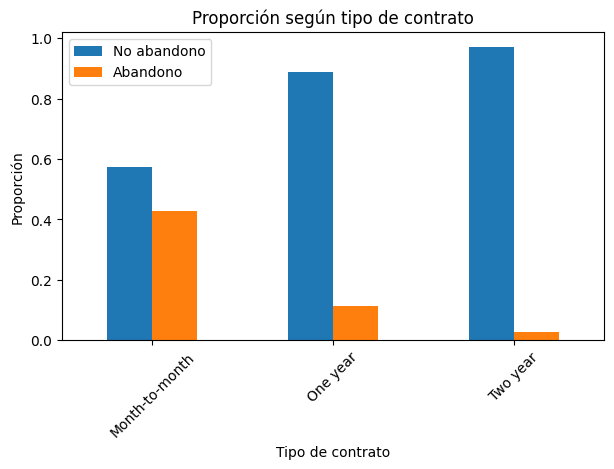

In [ ]:
import matplotlib.pyplot as plt

churn_contract = pd.crosstab(
    final_df["Type"],
    final_df["EndDate"],
    normalize="index"
)

churn_contract.plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Proporción según tipo de contrato")
plt.ylabel("Proporción")
plt.xlabel("Tipo de contrato")

plt.xticks(rotation=45)
plt.legend(["No abandono", "Abandono"])

plt.show()

Interpretación de la gráfica:  
La visualización muestra la proporción de abandono de clientes según el tipo de contrato. Se observa que los contratos Month-to-month presentan la mayor tasa de abandono, lo que indica que los clientes con compromisos cortos son más propensos a dejar el servicio. En contraste, los contratos de mayor duración (One year y Two year) registran una proporción significativamente menor de abandono, reflejando mayor fidelidad y permanencia. Este hallazgo sugiere que incentivar a los clientes a migrar hacia contratos más largos puede ser una estrategia efectiva para reducir el abandono y mejorar la retención.

### Antigüedad del cliente vs EndDate

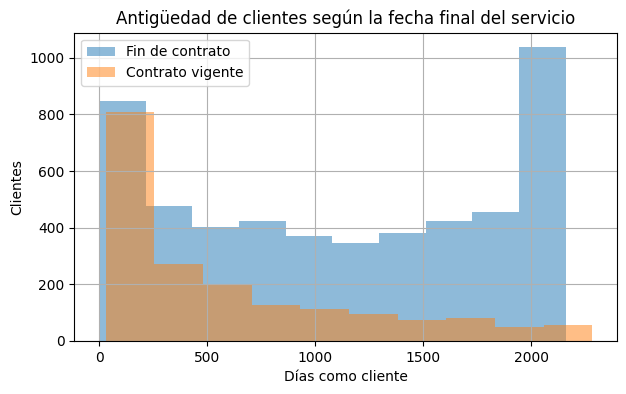

In [ ]:
plt.figure(figsize=(7,4))

final_df[final_df["EndDate"] == 0]["Antiguedad"].hist(
    alpha=0.5,
    label="Fin de contrato"
)

final_df[final_df["EndDate"] == 1]["Antiguedad"].hist(
    alpha=0.5,
    label="Contrato vigente"
)

plt.title("Antigüedad de clientes según la fecha final del servicio")
plt.xlabel("Días como cliente")
plt.ylabel("Clientes")

plt.legend()

plt.show()

Interpretación de la gráfica:  
La visualización compara la distribución de la antigüedad de los clientes (en días) entre aquellos que finalizaron su contrato y los que lo mantienen vigente. Se observa que los clientes con contratos terminados tienden a tener una antigüedad menor, lo que indica que el abandono ocurre con mayor frecuencia en etapas tempranas de la relación con la empresa. En contraste, los clientes con contratos vigentes muestran una distribución más amplia y con mayor concentración en periodos largos de permanencia, reflejando mayor fidelidad. Este hallazgo sugiere que las estrategias de retención deben enfocarse especialmente en los clientes nuevos durante sus primeros meses, ya que representan el grupo más vulnerable al abandono.

In [ ]:
#Codificamos las columnas necesarias para poder entrenar el modelo.
final_df["PaperlessBilling"] = final_df["PaperlessBilling"].apply(lambda x: 0 if x == "No" else 1)
final_df["gender"] = final_df["gender"].apply(lambda x: 0 if x == "Male" else 1)
final_df["Partner"] = final_df["Partner"].apply(lambda x: 0 if x == "No" else 1)
final_df["Dependents"] = final_df["Dependents"].apply(lambda x: 0 if x == "No" else 1)

In [ ]:
#Para estas columnas usamos One-Hot coding para las diferentes variabble que hay dentro de estas
final_df = pd.get_dummies(
    final_df,
    columns=[
        "Type",
        "PaymentMethod",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
        "MultipleLines"
    ],
    drop_first=True
)

### Grafica de distribucion de clases (variable objetivo)

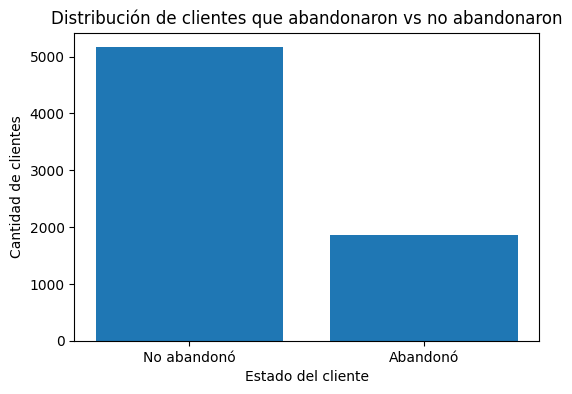

In [ ]:
leave_counts = final_df["EndDate"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(
    ["No abandonó", "Abandonó"],
    leave_counts.values
)

plt.title("Distribución de clientes que abandonaron vs no abandonaron")
plt.ylabel("Cantidad de clientes")
plt.xlabel("Estado del cliente")

plt.show()

Interpretación de la gráfica:  
La visualización muestra la cantidad de clientes que abandonaron el servicio frente a aquellos que permanecieron activos. Se observa que la mayoría de los clientes no abandonaron (aproximadamente 5000), mientras que un grupo menor sí abandonó (alrededor de 2000). Esto confirma que el dataset está desbalanceado, con una proporción significativamente mayor de clientes que permanecen en comparación con los que se dan de baja. Este hallazgo es relevante porque el desbalance puede afectar el desempeño de los modelos de clasificación, especialmente en la detección de la clase minoritaria (clientes que abandonan). Por ello, resulta recomendable aplicar técnicas de balanceo de clases o ajustar los umbrales de decisión para mejorar la capacidad del modelo de identificar correctamente a los clientes en riesgo de abandono.

### Preparacion de datos para el entrenamiento del modelo

In [ ]:
from sklearn.model_selection import train_test_split

#División del dataset en conjuntos de entrenamiento (60%), validación (20%) y test (20%)
df_train, df_temp = train_test_split(final_df, test_size=0.40, random_state=12345)
df_valid, df_test = train_test_split(df_temp, test_size=0.50, random_state=12345)

#Separación de características (features) y variable objetivo (target)
features_train = df_train.drop(["EndDate"], axis=1)
target_train = df_train["EndDate"]

features_valid = df_valid.drop(["EndDate"], axis=1)
target_valid = df_valid["EndDate"]

features_test = df_test.drop(["EndDate"], axis=1)
target_test = df_test["EndDate"]


### Modelo Regresion Logistica

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, precision_score, recall_score, f1_score

# Crear modelo
model = LogisticRegression(random_state=12345, solver="liblinear", max_iter=1000, class_weight="balanced")

# Entrenar modelo
model.fit(features_train, target_train)

# Predicciones de clase
predicted = model.predict(features_test)

# Probabilidades para AUC-ROC
predicted_proba = model.predict_proba(features_test)[:, 1]

# AUC-ROC (métrica principal)
auc = roc_auc_score(target_test, predicted_proba)
print("AUC-ROC:", auc)

# Precision
precision = precision_score(target_test, predicted)
print("Precision:", precision)

# Recall
recall = recall_score(target_test, predicted)
print("Recall:", recall)

# F1-score
f1 = f1_score(target_test, predicted)
print("F1-score:", f1)

# Reporte completo
print("\nReporte de clasificación:")
print(classification_report(target_test, predicted))

AUC-ROC: 0.8356544459616234
Precision: 0.5025906735751295
Recall: 0.7678100263852242
F1-score: 0.6075156576200418

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.89      0.72      0.80      1028
           1       0.50      0.77      0.61       379

    accuracy                           0.73      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.73      0.75      1407



Los resultados obtenidos son buenos; sin embargo, el valor de AUC-ROC se encuentra ligeramente por debajo del valor solicitado en el proyecto. A pesar de esto, el modelo presenta un desempeño aceptable y una buena capacidad para clasificar correctamente a los clientes.

### Prueba para el modelo Regresion Logistica

In [ ]:
# Predicciones finales para el modelo regresion logistica
predicted_test_r = model.predict(features_test)

# Probabilidades para AUC-ROC
predicted_proba_test_r = model.predict_proba(features_test)[:, 1]

# AUC-ROC (métrica principal)
auc_test_r = roc_auc_score(target_test, predicted_proba_test_r)
print("AUC-ROC en test:", auc_test_r)

# F1-score
f1_test_r = f1_score(target_test, predicted_test_r)
print("F1-score en test:", f1_test_r)

# Reporte completo
print("\nReporte de clasificación:")
print(classification_report(target_test, predicted_test_r))

AUC-ROC en test: 0.8356544459616234
F1-score en test: 0.6075156576200418

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.89      0.72      0.80      1028
           1       0.50      0.77      0.61       379

    accuracy                           0.73      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.73      0.75      1407



El modelo de Regresión Logística obtuvo un AUC-ROC de 0.8356, mostrando un buen desempeño en la clasificación de clientes. Sin embargo, aunque el resultado es aceptable, se encuentra por debajo del valor objetivo, por lo que se evaluaron otros modelos para mejorar la métrica principal.

### Modelo de Bosque aleatorio

In [ ]:
 #Creación y entrenamiento del modelo final
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

final_model = RandomForestClassifier(n_estimators=100, random_state=12345, max_depth=8, min_samples_leaf=5, class_weight="balanced")
final_model.fit(features_train, target_train)

#Evaluación del modelo
predicted_proba_r = final_model.predict_proba(features_valid)[:, 1]

auc_r = roc_auc_score(target_valid, predicted_proba_r)
print("AUC-ROC:", auc_r)

predicted_valid = final_model.predict(features_valid)

# Métricas adicionales
precision = precision_score(target_valid, predicted_valid)
recall = recall_score(target_valid, predicted_valid)
f1 = f1_score(target_valid, predicted_valid)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

# Reporte completo por clase
print("\nReporte de clasificación:\n", classification_report(target_valid, predicted_valid))

AUC-ROC: 0.8740287551311051
Precision: 0.5576208178438662
Recall: 0.8152173913043478
F1-score: 0.662251655629139

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.92      0.77      0.84      1038
           1       0.56      0.82      0.66       368

    accuracy                           0.78      1406
   macro avg       0.74      0.79      0.75      1406
weighted avg       0.83      0.78      0.79      1406



Durante la configuración del modelo de Bosque Aleatorio se detectó sobreajuste, por lo que se ajustaron sus hiperparámetros para mejorar la generalización del modelo. Después de estos cambios, se redujo la diferencia entre entrenamiento y validación, obteniendo además un AUC-ROC superior al modelo de Regresión Logística, por lo que fue seleccionado como modelo final.

### Prueba para el Bosque aleatorio

In [ ]:
# Evaluación final del modelo Random Forest con test
predicted_test = final_model.predict(features_test)

# Probabilidades de la clase positiva
predicted_proba_test = final_model.predict_proba(features_test)[:, 1]

# AUC-ROC (métrica principal)
auc_test = roc_auc_score(target_test, predicted_proba_test)
print("AUC-ROC en test:", auc_test)

precision_test = precision_score(target_test, predicted_test)
recall_test = recall_score(target_test, predicted_test)
f1_test = f1_score(target_test, predicted_test)

print("Precision en test:", precision_test)
print("Recall en test:", recall_test)
print("F1-score en test:", f1_test)

# Reporte completo
print("\nReporte de clasificación en test:\n", classification_report(target_test, predicted_test))

AUC-ROC en test: 0.8552688315554962
Precision en test: 0.5728155339805825
Recall en test: 0.7783641160949868
F1-score en test: 0.6599552572706935

Reporte de clasificación en test:
               precision    recall  f1-score   support

           0       0.91      0.79      0.84      1028
           1       0.57      0.78      0.66       379

    accuracy                           0.78      1407
   macro avg       0.74      0.78      0.75      1407
weighted avg       0.82      0.78      0.79      1407



El modelo de Bosque Aleatorio obtuvo un AUC-ROC de 0.8552, superando el rendimiento de la Regresión Logística. Por esta razón, se selecciona como modelo final, ya que presenta una mejor capacidad para clasificar clientes con riesgo de abandono y capturar relaciones complejas entre las variables del dataset.

### Conclusiones

Durante el desarrollo del proyecto se realizó la preparación del dataset, incluyendo la limpieza de datos, transformación de variables categóricas mediante One-Hot Encoding. Además, se realizó una división de los datos en entrenamiento, validación y prueba para evaluar correctamente el desempeño de los modelos.

Se evaluaron dos algoritmos de clasificación: Regresión Logística y Bosque Aleatorio. La Regresión Logística obtuvo un AUC-ROC de 0.8356, con un buen nivel de detección de clientes que abandonan, aunque presentó limitaciones para diferenciar correctamente algunos casos debido a la complejidad de los patrones presentes en los datos.

Posteriormente, se entrenó un modelo de Bosque Aleatorio, donde se ajustaron sus hiperparámetros para reducir el sobreajuste y mejorar la capacidad de generalización. Este modelo obtuvo un AUC-ROC superior de 0.8552, por lo que fue seleccionado como modelo final.

En conclusión, el modelo de Bosque Aleatorio presentó el mejor desempeño para la predicción de abandono de clientes, logrando una mayor capacidad de clasificación que la Regresión Logística. Aunque el resultado obtenido no alcanzó el valor máximo esperado del proyecto, el modelo presenta un desempeño adecuado y puede utilizarse como apoyo para identificar clientes con mayor probabilidad de abandonar el servicio.

Acciones recomendadas para la empresa.

Segmentación de clientes en riesgo:  
Usar las predicciones del modelo para identificar a los clientes con mayor probabilidad de abandono y crear listas de seguimiento.

Campañas de retención personalizadas:  
Ofrecer descuentos, beneficios exclusivos o programas de fidelización dirigidos específicamente a los clientes clasificados como de alto riesgo.

Mejora del servicio al cliente:  
Priorizar la atención proactiva (llamadas, correos, soporte dedicado) hacia los clientes que el modelo señala como más propensos a abandonar.

Análisis de patrones de abandono:  
Revisar las variables más influyentes en el modelo (importancia de características) para entender qué factores están asociados al churn y tomar decisiones de negocio (ej. mejorar tiempos de respuesta, ajustar precios, optimizar procesos).

Monitoreo continuo:  
Integrar el modelo en un flujo automatizado que se ejecute periódicamente, para actualizar las predicciones y detectar cambios en el comportamiento de los clientes.